# WP3 — Partie 2 : Entraînement baseline de la projection MLP

### 2.1 Chargement des paires

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')

data_train = torch.load('pairs_train.pt')
data_val = torch.load('pairs_val.pt')

train_ds = TensorDataset(data_train['z_full'], data_train['z_clip'])
val_ds = TensorDataset(data_val['z_full'], data_val['z_clip'])

BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train : {len(train_ds)} paires')
print(f'Val   : {len(val_ds)} paires')

Device : cpu
Train : 117000 paires
Val   : 13000 paires


### 2.2 Architecture MLP baseline

In [2]:
class ProjectionMLP(nn.Module):
    """
    Baseline : Linear -> GELU -> LayerNorm -> Linear -> L2 norm
    """
    def __init__(self, in_dim=1024, hidden_dim=1024, out_dim=768):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


model = ProjectionMLP().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'Parametres : {n_params:,}')


Parametres : 1,838,848


### 2.3 Loss cosinus

In [3]:
def projection_loss(z_mae, z_clip):
    """
    Loss cosinus : 1 - cos(z_mae, z_clip).
    0 si parfaitement aligne, 2 si opposes.
    Coherente avec la geometrie L2-normalisee de CLIP.
    """
    return (1 - F.cosine_similarity(z_mae, z_clip)).mean()


### 2.4 Entraînement

In [4]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

N_EPOCHS = 100
LR = 1e-3
WEIGHT_DECAY = 1e-4

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

history = {'train_loss': [], 'val_loss': [], 'val_cos_sim': []}
best_cos, best_epoch = 0., 0


def eval_epoch(loader):
    model.eval()
    total_loss, total_cos, n = 0., 0., 0
    with torch.no_grad():
        for z_full, z_clip in loader:
            z_full, z_clip = z_full.to(DEVICE), z_clip.to(DEVICE)
            z_proj = model(z_full)
            loss = projection_loss(z_proj, z_clip)
            cos = F.cosine_similarity(z_proj, z_clip).mean()
            B = z_full.shape[0]
            total_loss += loss.item() * B
            total_cos += cos.item() * B
            n += B
    return total_loss / n, total_cos / n


for epoch in range(N_EPOCHS):
    model.train()
    total_loss, n = 0., 0
    for z_full, z_clip in train_loader:
        z_full, z_clip = z_full.to(DEVICE), z_clip.to(DEVICE)
        optimizer.zero_grad()
        z_proj = model(z_full)
        loss = projection_loss(z_proj, z_clip)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * z_full.shape[0]
        n += z_full.shape[0]
    scheduler.step()

    train_loss = total_loss / n
    val_loss, val_cos = eval_epoch(val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_cos_sim'].append(val_cos)

    # Early stopping — sauvegarder le meilleur modele
    if val_cos > best_cos:
        best_cos, best_epoch = val_cos, epoch + 1
        torch.save(model.state_dict(), 'projection_mlp_best.pt')

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{N_EPOCHS} | '
              f'train_loss={train_loss:.4f} | '
              f'val_loss={val_loss:.4f} | '
              f'val_cos={val_cos:.4f} | '
              f'lr={scheduler.get_last_lr()[0]:.2e}')

print(f'Meilleur modele : epoch {best_epoch}, val_cos={best_cos:.4f}')
print('Sauvegarde -> projection_mlp_best.pt')

Epoch  10/100 | train_loss=0.1038 | val_loss=0.1111 | val_cos=0.8889 | lr=9.76e-04
Epoch  20/100 | train_loss=0.0960 | val_loss=0.1114 | val_cos=0.8886 | lr=9.05e-04
Epoch  30/100 | train_loss=0.0919 | val_loss=0.1127 | val_cos=0.8873 | lr=7.94e-04
Epoch  40/100 | train_loss=0.0886 | val_loss=0.1136 | val_cos=0.8864 | lr=6.55e-04
Epoch  50/100 | train_loss=0.0862 | val_loss=0.1149 | val_cos=0.8851 | lr=5.00e-04
Epoch  60/100 | train_loss=0.0843 | val_loss=0.1161 | val_cos=0.8839 | lr=3.45e-04
Epoch  70/100 | train_loss=0.0828 | val_loss=0.1165 | val_cos=0.8835 | lr=2.06e-04
Epoch  80/100 | train_loss=0.0817 | val_loss=0.1171 | val_cos=0.8829 | lr=9.55e-05
Epoch  90/100 | train_loss=0.0811 | val_loss=0.1174 | val_cos=0.8826 | lr=2.45e-05
Epoch 100/100 | train_loss=0.0808 | val_loss=0.1175 | val_cos=0.8825 | lr=0.00e+00
Meilleur modele : epoch 14, val_cos=0.8894
Sauvegarde -> projection_mlp_best.pt


### 2.5 Courbes d'entraînement

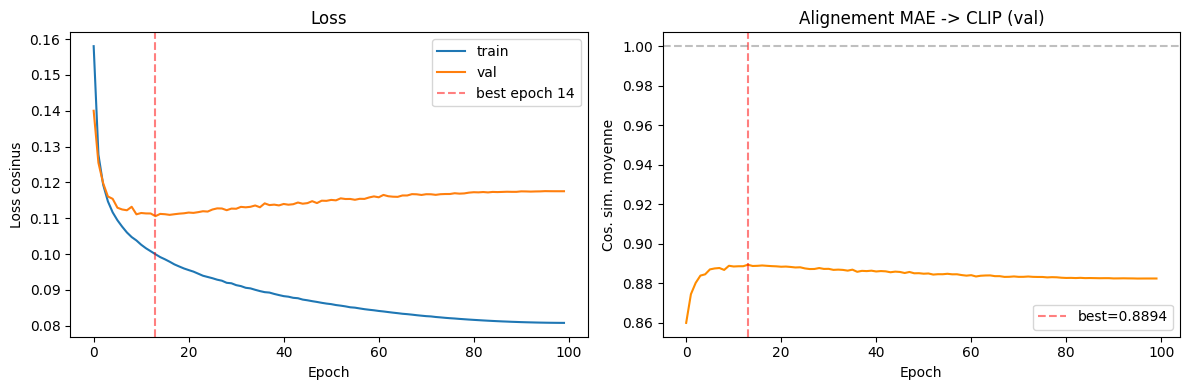

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5, label=f'best epoch {best_epoch}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss cosinus')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history['val_cos_sim'], color='darkorange')
axes[1].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5, label=f'best={best_cos:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Cos. sim. moyenne')
axes[1].set_title('Alignement MAE -> CLIP (val)')
axes[1].axhline(1.0, color='gray', linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()